In [67]:
from google.colab import files

uploaded = files.upload()

Saving global_ecommerce_sales.csv to global_ecommerce_sales (1).csv


In [68]:
import pandas as pd

df = pd.read_csv("global_ecommerce_sales.csv")

df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,02-01-2023,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,02-01-2023,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,03-01-2023,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,03-01-2023,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,05-01-2023,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [65]:
df.shape

(2000, 15)

In [64]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost',
       'Profit', 'Payment_Method'],
      dtype='object')

In [63]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
Customer_Segment,0
Country,0
Region,0
Product_Category,0
Product_Name,0
Quantity,0
Unit_Price,0


In [62]:
df.dtypes

,0
Order_ID,object
Order_Date,datetime64[ns]
Customer_Name,object
Customer_Segment,object
Country,object
Region,object
Product_Category,object
Product_Name,object
Quantity,int64
Unit_Price,float64


In [61]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)

df.dtypes

,0
Order_ID,object
Order_Date,datetime64[ns]
Customer_Name,object
Customer_Segment,object
Country,object
Region,object
Product_Category,object
Product_Name,object
Quantity,int64
Unit_Price,float64


In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.describe()


,Order_Date,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,2024-07-12 03:17:16.800000,3.557500,73.329490,8.572500,242.279670,12.90212,79.436160
min,2023-01-02 00:00:00,1.000000,3.030000,0.000000,2.420000,5.52000,-11.280000
25%,2023-10-08 00:00:00,2.000000,18.757500,0.000000,41.227500,9.45750,6.865000
50%,2024-07-12 12:00:00,3.000000,46.420000,10.000000,113.125000,11.84500,32.830000
75%,2025-04-20 06:00:00,5.000000,90.250000,15.000000,266.552500,14.92000,90.297500
max,2025-12-31 00:00:00,15.000000,472.560000,30.000000,3813.980000,40.44000,1373.630000
std,NaN,2.704506,79.311014,7.261274,382.583802,5.22319,137.573593


In [58]:
total_revenue = df["Total_Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
average_order_value = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Profit Margin:", round(profit_margin, 2), "%")

Total Revenue: 484559.34
Total Profit: 158872.32
Total Orders: 2000
Average Order Value: 242.28
Profit Margin: 32.79 %


In [57]:
category_sales = (
    df.groupby("Product_Category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Total_Sales
Product_Category,
Furniture,256274.68
Technology,139518.22
Clothing & Accessories,69375.63
Office Supplies,19390.81


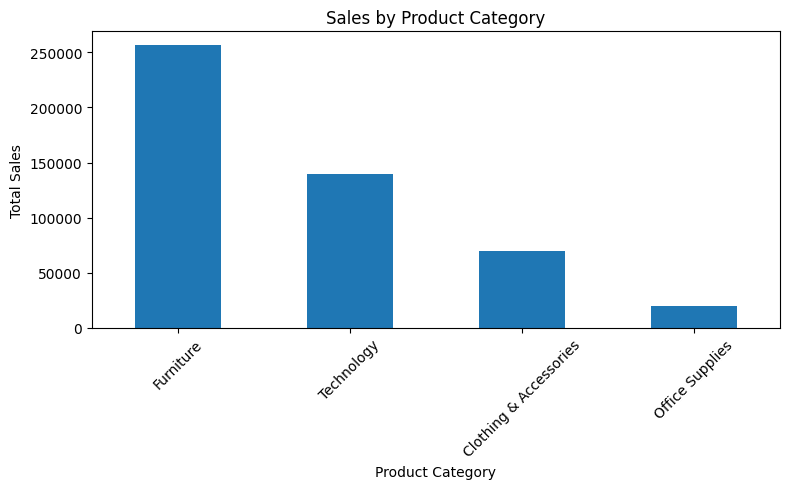

In [56]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
category_profit = (
    df.groupby("Product_Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

,Profit
Product_Category,
Furniture,81171.57
Technology,48268.65
Clothing & Accessories,26112.94
Office Supplies,3319.16


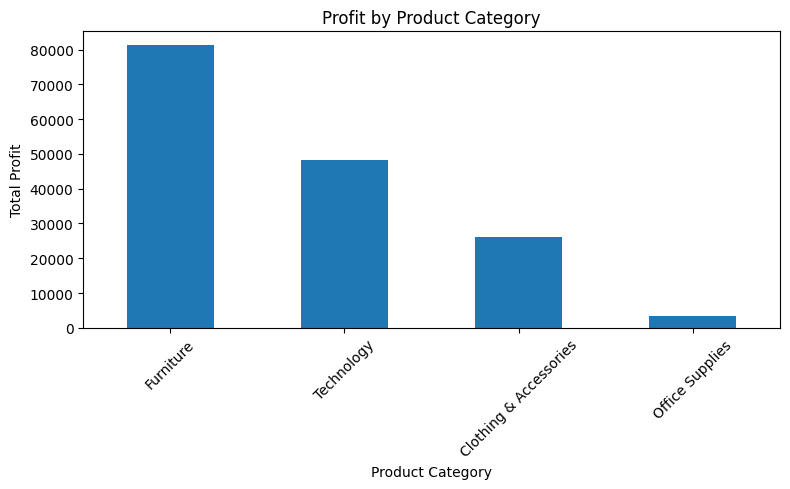

In [54]:
category_profit.plot(kind="bar", figsize=(8, 5))

plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
country_sales = (
    df.groupby("Country")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

country_sales

,Total_Sales
Country,
Mexico,47217.30
Canada,45326.55
United States,41332.53
Japan,30950.19
United Kingdom,30185.46
Germany,28989.73
China,28322.85
Italy,27484.38
France,26616.81


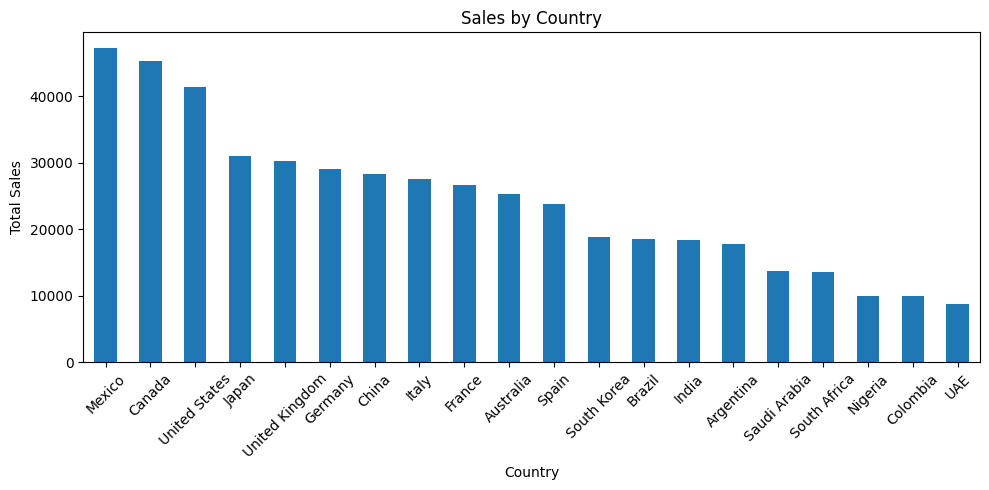

In [52]:
country_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
segment_sales = (
    df.groupby("Customer_Segment")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_sales

,Total_Sales
Customer_Segment,
Consumer,256287.74
Corporate,146050.39
Home Office,82221.21


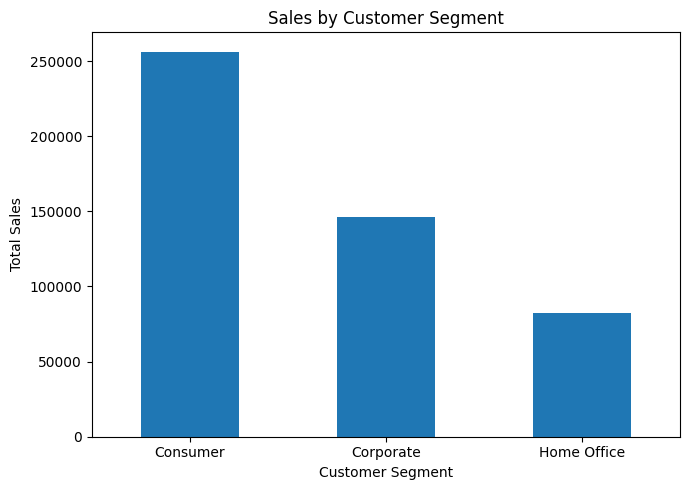

In [50]:
segment_sales.plot(kind="bar", figsize=(7, 5))

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Total_Sales"]
    .sum()
)

monthly_sales

,Total_Sales
Order_Date,
2023-01,11275.20
2023-02,16943.67
2023-03,16056.45
2023-04,12185.00
2023-05,8218.47
2023-06,16191.61
2023-07,15667.73
2023-08,12971.07
2023-09,11989.72


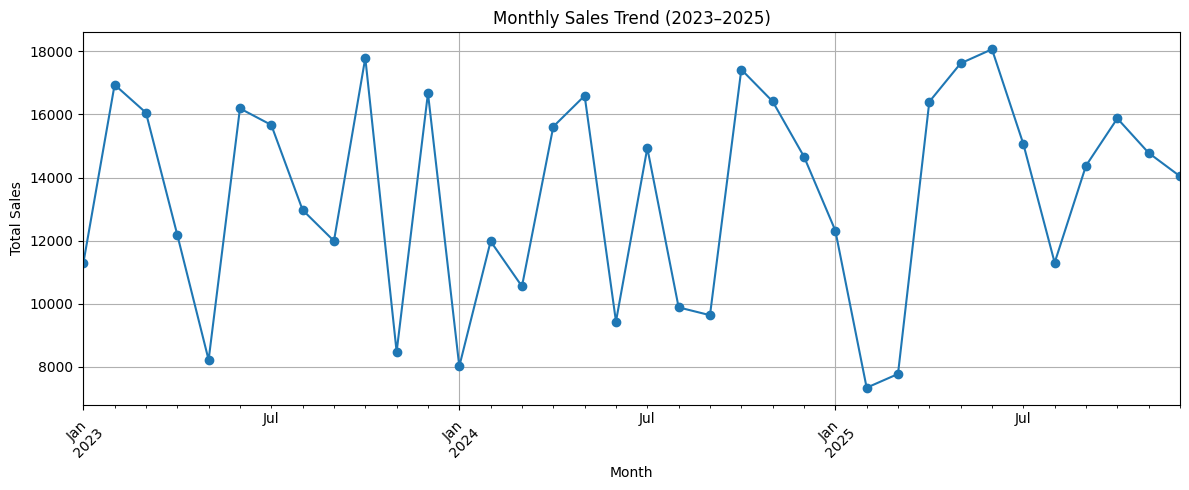

In [48]:
monthly_sales.plot(kind="line", figsize=(12, 5), marker="o")

plt.title("Monthly Sales Trend (2023–2025)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

customer_data = df.groupby("Customer_Name").agg(
    Total_Sales=("Total_Sales", "sum"),
    Total_Orders=("Order_ID", "nunique"),
    Total_Quantity=("Quantity", "sum")
)

customer_data.head()

,Total_Sales,Total_Orders,Total_Quantity
Customer_Name,,,
Ahmed Ali,509.12,1,12
Ahmed Anderson,133.68,1,4
Ahmed Clark,94.28,2,4
Ahmed Dubois,105.73,3,3
Ahmed Garcia,1769.48,2,14


In [46]:
features = customer_data[
    ["Total_Sales", "Total_Orders", "Total_Quantity"]
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 0.42650628, -0.53616372,  1.93647471],
       [-0.40213791, -0.53616372, -0.16787468],
       [-0.48909876,  1.22880441, -0.16787468],
       [-0.46382715,  2.99377255, -0.43091835],
       [ 3.20828231,  1.22880441,  2.46256205]])

In [45]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

customer_data["Cluster"] = kmeans.fit_predict(scaled_features)

customer_data.head()

,Total_Sales,Total_Orders,Total_Quantity,Cluster,Customer_Segment_AI
Customer_Name,,,,,
Ahmed Ali,509.12,1,12,2,Medium-Value Customers
Ahmed Anderson,133.68,1,4,0,Lower-Value Customers
Ahmed Clark,94.28,2,4,2,Medium-Value Customers
Ahmed Dubois,105.73,3,3,2,Medium-Value Customers
Ahmed Garcia,1769.48,2,14,1,High-Value Customers


In [44]:
cluster_summary = customer_data.groupby("Cluster").agg(
    Customers=("Total_Sales", "count"),
    Average_Sales=("Total_Sales", "mean"),
    Average_Orders=("Total_Orders", "mean"),
    Average_Quantity=("Total_Quantity", "mean")
).round(2)

cluster_summary

,Customers,Average_Sales,Average_Orders,Average_Quantity
Cluster,,,,
0,1088,183.20,1.00,3.22
1,92,1736.15,1.68,11.47
2,354,354.56,2.14,7.23


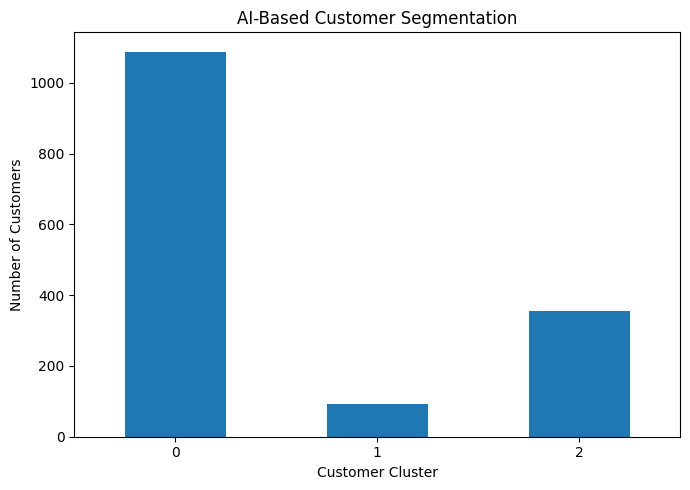

In [43]:
cluster_counts = customer_data["Cluster"].value_counts().sort_index()

cluster_counts.plot(kind="bar", figsize=(7, 5))

plt.title("AI-Based Customer Segmentation")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

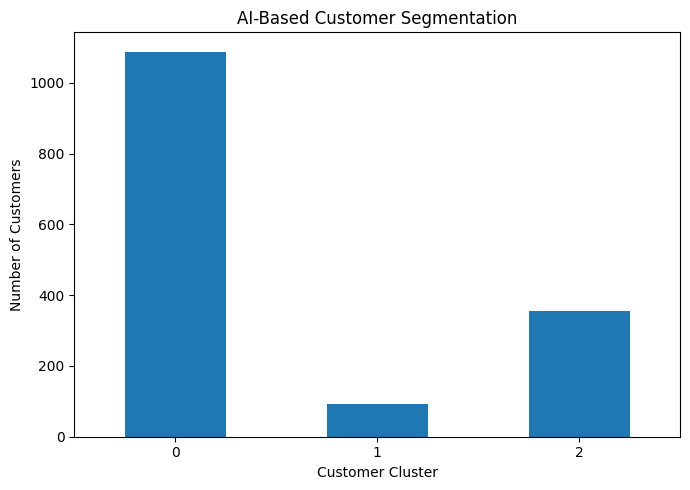

In [42]:
cluster_counts = customer_data["Cluster"].value_counts().sort_index()

cluster_counts.plot(kind="bar", figsize=(7, 5))

plt.title("AI-Based Customer Segmentation")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
cluster_summary.sort_values("Average_Sales", ascending=False)

,Customers,Average_Sales,Average_Orders,Average_Quantity
Cluster,,,,
1,92,1736.15,1.68,11.47
2,354,354.56,2.14,7.23
0,1088,183.20,1.00,3.22


In [40]:
cluster_summary.sort_values("Average_Sales", ascending=False)

,Customers,Average_Sales,Average_Orders,Average_Quantity
Cluster,,,,
1,92,1736.15,1.68,11.47
2,354,354.56,2.14,7.23
0,1088,183.20,1.00,3.22


In [39]:
cluster_names = {
    1: "High-Value Customers",
    2: "Medium-Value Customers",
    0: "Lower-Value Customers"
}

customer_data["Customer_Segment_AI"] = customer_data["Cluster"].map(cluster_names)

customer_data.head()

,Total_Sales,Total_Orders,Total_Quantity,Cluster,Customer_Segment_AI
Customer_Name,,,,,
Ahmed Ali,509.12,1,12,2,Medium-Value Customers
Ahmed Anderson,133.68,1,4,0,Lower-Value Customers
Ahmed Clark,94.28,2,4,2,Medium-Value Customers
Ahmed Dubois,105.73,3,3,2,Medium-Value Customers
Ahmed Garcia,1769.48,2,14,1,High-Value Customers


In [38]:
ai_segment_counts = (
    customer_data["Customer_Segment_AI"]
    .value_counts()
)

ai_segment_counts

,count
Customer_Segment_AI,
Lower-Value Customers,1088
Medium-Value Customers,354
High-Value Customers,92


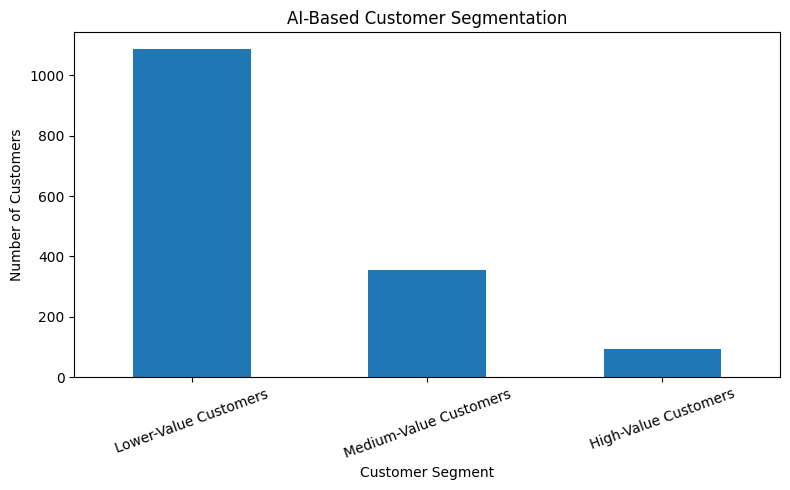

In [37]:
ai_segment_counts.plot(kind="bar", figsize=(8, 5))

plt.title("AI-Based Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [36]:
ai_segment_summary = customer_data.groupby(
    "Customer_Segment_AI"
).agg(
    Customers=("Total_Sales", "count"),
    Average_Sales=("Total_Sales", "mean"),
    Average_Orders=("Total_Orders", "mean"),
    Average_Quantity=("Total_Quantity", "mean")
).round(2)

ai_segment_summary

,Customers,Average_Sales,Average_Orders,Average_Quantity
Customer_Segment_AI,,,,
High-Value Customers,92,1736.15,1.68,11.47
Lower-Value Customers,1088,183.20,1.00,3.22
Medium-Value Customers,354,354.56,2.14,7.23


In [35]:
customer_data.to_csv(
    "AI_Customer_Segmentation.csv",
    index=True
)

print("AI customer segmentation file created successfully.")

AI customer segmentation file created successfully.


## AI-Based Customer Segmentation

K-Means clustering was used to segment customers based on their purchasing behavior.

The model used:
- Total Sales
- Total Orders
- Total Quantity

StandardScaler was applied before clustering so that the numerical features were on a comparable scale.

Three customer groups were created using K-Means clustering. The clusters were interpreted based on their average sales values and labeled as:
- High-Value Customers
- Medium-Value Customers
- Lower-Value Customers

This AI-based segmentation helps identify different customer groups and can support targeted marketing, customer engagement, and business decision-making.

# Global E-Commerce Sales & Customer Analytics with AI

## Project Overview

This project analyzes global e-commerce sales and customer transaction data to identify sales trends, profitable product categories, high-performing countries, customer segments, and purchasing patterns.

Python and Pandas are used for data analysis and visualization, while K-Means clustering is used as an AI-based technique to segment customers according to their purchasing behavior.

## Objectives

- Analyze overall sales and profitability.
- Identify high-performing product categories and countries.
- Analyze customer segments and sales trends.
- Study monthly sales performance.
- Apply AI-based customer segmentation using K-Means clustering.
- Generate business insights that can support data-driven decision-making.

## Dataset

**Dataset:** Global E-Commerce Sales & Customer Data

**Source:** Kaggle

**Dataset link:**  
https://www.kaggle.com/datasets/muhammadaammartufail/global-e-commerce-sales-and-customer-data

## Technologies Used

- Python
- Google Colab / Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Excel
- Power BI
- K-Means Clustering
- GitHub

## Data Analysis

The dataset was loaded into Python using Pandas. Data quality checks were performed to identify missing values and duplicate records. The order date was converted into a proper datetime format for time-based analysis.

The analysis includes:

1. Dataset structure and statistical summary
2. Overall revenue, profit, orders, average order value, and profit margin
3. Sales by product category
4. Profit by product category
5. Sales by country
6. Sales by customer segment
7. Monthly sales trends
8. AI-based customer segmentation using K-Means clustering

## Conclusion

The project provides an analytical view of global e-commerce sales and customer behavior. Python-based analysis was used to calculate key business metrics, identify sales and profit patterns, and visualize trends across products, countries, customer segments, and time periods.

K-Means clustering was also applied to group customers according to their purchasing behavior. The resulting customer segments provide an AI-based approach for understanding differences in customer value and supporting data-driven business decisions.

The project demonstrates the use of data analytics, visualization, and machine learning techniques in an e-commerce business context.

In [71]:
df[[
    "Quantity",
    "Unit_Price",
    "Discount",
    "Shipping_Cost",
    "Total_Sales"
]].head()

KeyError: "['Discount'] not in index"

In [72]:
df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Customer_Name',
 'Customer_Segment',
 'Country',
 'Region',
 'Product_Category',
 'Product_Name',
 'Quantity',
 'Unit_Price',
 'Discount_Percent',
 'Total_Sales',
 'Shipping_Cost',
 'Profit',
 'Payment_Method']

In [73]:
df[[
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Shipping_Cost",
    "Total_Sales"
]].head()

,Quantity,Unit_Price,Discount_Percent,Shipping_Cost,Total_Sales
0,3,99.43,0,9.31,298.29
1,4,97.93,20,14.31,313.38
2,2,10.74,0,8.12,21.48
3,2,61.86,15,10.79,105.16
4,4,330.67,20,11.09,1058.14


In [74]:
df[[
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Shipping_Cost",
    "Total_Sales"
]].corr()

,Quantity,Unit_Price,Discount_Percent,Shipping_Cost,Total_Sales
Quantity,1.000000,0.020364,0.005010,0.766924,0.503233
Unit_Price,0.020364,1.000000,0.021263,0.017095,0.701605
Discount_Percent,0.005010,0.021263,1.000000,0.015693,-0.045900
Shipping_Cost,0.766924,0.017095,0.015693,1.000000,0.385902
Total_Sales,0.503233,0.701605,-0.045900,0.385902,1.000000


In [75]:
X = df[
    [
        "Quantity",
        "Unit_Price",
        "Discount_Percent",
        "Shipping_Cost"
    ]
]

y = df["Total_Sales"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Input features:
['Quantity', 'Unit_Price', 'Discount_Percent', 'Shipping_Cost']

Target:
Total_Sales


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 1600
Testing records: 400


In [77]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Sales prediction model trained successfully.")

Sales prediction model trained successfully.


In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error: 18.49
Root Mean Squared Error: 69.77
R² Score: 0.96


In [79]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
1,Unit_Price,0.562120
0,Quantity,0.418744
3,Shipping_Cost,0.012825
2,Discount_Percent,0.006311


In [80]:
sample_order = pd.DataFrame({
    "Quantity": [3],
    "Unit_Price": [150],
    "Discount_Percent": [10],
    "Shipping_Cost": [12]
})

predicted_sales = model.predict(sample_order)

print("Predicted Sales:", round(predicted_sales[0], 2))

Predicted Sales: 404.26


In [81]:
import joblib

joblib.dump(model, "sales_prediction_model.pkl")

print("Sales prediction model saved successfully.")

Sales prediction model saved successfully.


In [82]:
joblib.dump(kmeans, "customer_segmentation_model.pkl")
joblib.dump(scaler, "customer_segmentation_scaler.pkl")

print("Customer segmentation model and scaler saved successfully.")

Customer segmentation model and scaler saved successfully.


In [83]:
import os

files = [
    "sales_prediction_model.pkl",
    "customer_segmentation_model.pkl",
    "customer_segmentation_scaler.pkl"
]

for file in files:
    print(file, "->", os.path.exists(file))

sales_prediction_model.pkl -> True
customer_segmentation_model.pkl -> True
customer_segmentation_scaler.pkl -> True


In [84]:
requirements = """pandas
numpy
matplotlib
scikit-learn
streamlit
plotly
openpyxl
joblib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully.")

requirements.txt created successfully.


In [85]:
with open("requirements.txt", "r") as file:
    print(file.read())

pandas
numpy
matplotlib
scikit-learn
streamlit
plotly
openpyxl
joblib



In [86]:
backend_code = '''
import joblib
import pandas as pd

# Load trained sales prediction model
sales_model = joblib.load("sales_prediction_model.pkl")

# Load customer segmentation model and scaler
customer_model = joblib.load("customer_segmentation_model.pkl")
customer_scaler = joblib.load("customer_segmentation_scaler.pkl")


def predict_sales(quantity, unit_price, discount_percent, shipping_cost):
    data = pd.DataFrame({
        "Quantity": [quantity],
        "Unit_Price": [unit_price],
        "Discount_Percent": [discount_percent],
        "Shipping_Cost": [shipping_cost]
    })

    prediction = sales_model.predict(data)

    return prediction[0]
'''

with open("model.py", "w") as file:
    file.write(backend_code)

print("model.py created successfully.")

model.py created successfully.


In [87]:
with open("model.py", "r") as file:
    print(file.read())


import joblib
import pandas as pd

# Load trained sales prediction model
sales_model = joblib.load("sales_prediction_model.pkl")

# Load customer segmentation model and scaler
customer_model = joblib.load("customer_segmentation_model.pkl")
customer_scaler = joblib.load("customer_segmentation_scaler.pkl")


def predict_sales(quantity, unit_price, discount_percent, shipping_cost):
    data = pd.DataFrame({
        "Quantity": [quantity],
        "Unit_Price": [unit_price],
        "Discount_Percent": [discount_percent],
        "Shipping_Cost": [shipping_cost]
    })

    prediction = sales_model.predict(data)

    return prediction[0]



In [88]:
app_code = '''
import streamlit as st
from model import predict_sales

st.set_page_config(
    page_title="Global E-Commerce AI Analytics",
    page_icon="🛒",
    layout="wide"
)

st.title("🛒 Global E-Commerce Sales Prediction")
st.write("AI-powered sales prediction using a Random Forest model.")

st.subheader("Enter Order Details")

quantity = st.number_input(
    "Quantity",
    min_value=1,
    value=1,
    step=1
)

unit_price = st.number_input(
    "Unit Price",
    min_value=0.0,
    value=100.0,
    step=10.0
)

discount_percent = st.number_input(
    "Discount (%)",
    min_value=0.0,
    max_value=100.0,
    value=0.0,
    step=5.0
)

shipping_cost = st.number_input(
    "Shipping Cost",
    min_value=0.0,
    value=10.0,
    step=1.0
)

if st.button("Predict Sales"):
    prediction = predict_sales(
        quantity,
        unit_price,
        discount_percent,
        shipping_cost
    )

    st.success(f"Predicted Sales: {prediction:.2f}")
'''

with open("app.py", "w") as file:
    file.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [90]:
with open("app.py", "r") as file:
    print(file.read())


import streamlit as st
from model import predict_sales

st.set_page_config(
    page_title="Global E-Commerce AI Analytics",
    page_icon="🛒",
    layout="wide"
)

st.title("🛒 Global E-Commerce Sales Prediction")
st.write("AI-powered sales prediction using a Random Forest model.")

st.subheader("Enter Order Details")

quantity = st.number_input(
    "Quantity",
    min_value=1,
    value=1,
    step=1
)

unit_price = st.number_input(
    "Unit Price",
    min_value=0.0,
    value=100.0,
    step=10.0
)

discount_percent = st.number_input(
    "Discount (%)",
    min_value=0.0,
    max_value=100.0,
    value=0.0,
    step=5.0
)

shipping_cost = st.number_input(
    "Shipping Cost",
    min_value=0.0,
    value=10.0,
    step=1.0
)

if st.button("Predict Sales"):
    prediction = predict_sales(
        quantity,
        unit_price,
        discount_percent,
        shipping_cost
    )

    st.success(f"Predicted Sales: {prediction:.2f}")



In [94]:
!pip install -q streamlit

In [95]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [99]:
!streamlit run app.py &>/content/streamlit.log &

In [100]:
!lt --port 8501

your url is: https://eight-dogs-check.loca.lt
^C


In [101]:
!lt --port 8501 --local-host 127.0.0.1

your url is: https://forty-maps-wait.loca.lt
^C


In [102]:
!cat /content/streamlit.log



2026-09-24 10:45:49.686 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.162.234:8501

  Stopping...


In [105]:
!streamlit run app.py



2026-09-24 11:07:52.772 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.162.234:8501

  Stopping...
  Stopping...


In [106]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package cloudflared.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.9.1) ...
Setting up cloudflared (2026.9.1) ...
Processing triggers for man-db (2.12.0-4build2) ...


In [108]:
!streamlit run app.py > streamlit.log 2>&1 &

In [109]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-09-24T11:16:00Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-24T11:16:00Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-24T11:16:05Z INF +--------------------------------------------------------------------------------------------+
2026-09-24T11:16:05Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-24T11:16:05Z INF |  https://scholar-monica-stuffed-ons.trycloudflare.com 

In [110]:
!cp app.py app_backup.py

In [111]:
import os

print(os.path.exists("global_ecommerce_sales.csv"))

True


In [112]:
import pandas as pd

df_check = pd.read_csv("global_ecommerce_sales.csv")

print("Rows:", len(df_check))
print("Columns:", len(df_check.columns))
print(df_check.columns.tolist())

Rows: 2000
Columns: 15
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost', 'Profit', 'Payment_Method']


In [104]:
!lt --port 8501 --local-host 127.0.0.1

your url is: https://thin-rabbits-hunt.loca.lt
^C


In [113]:
!pkill -f "streamlit run app.py"

In [114]:
app_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px

from model import predict_sales

# -----------------------------
# Page Configuration
# -----------------------------
st.set_page_config(
    page_title="Global E-Commerce AI Analytics",
    page_icon="🛒",
    layout="wide"
)

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("global_ecommerce_sales.csv")

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    dayfirst=True
)

# -----------------------------
# Page Title
# -----------------------------
st.title("🛒 Global E-Commerce Sales & Customer Analytics")
st.write(
    "AI-powered e-commerce analytics, customer segmentation "
    "and sales prediction."
)

# -----------------------------
# KPI Calculations
# -----------------------------
total_revenue = df["Total_Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
average_order_value = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

# -----------------------------
# KPI Dashboard
# -----------------------------
st.subheader("📊 Business Overview")

col1, col2, col3, col4, col5 = st.columns(5)

col1.metric(
    "Total Revenue",
    f"₹{total_revenue:,.2f}"
)

col2.metric(
    "Total Profit",
    f"₹{total_profit:,.2f}"
)

col3.metric(
    "Total Orders",
    f"{total_orders:,}"
)

col4.metric(
    "Average Order Value",
    f"₹{average_order_value:,.2f}"
)

col5.metric(
    "Profit Margin",
    f"{profit_margin:.2f}%"
)

st.divider()

# -----------------------------
# Sales by Category
# -----------------------------
st.subheader("📦 Sales by Product Category")

category_sales = (
    df.groupby("Product_Category")["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

fig_category = px.bar(
    category_sales,
    x="Product_Category",
    y="Total_Sales",
    title="Sales by Product Category",
    labels={
        "Total_Sales": "Total Sales",
        "Product_Category": "Product Category"
    }
)

st.plotly_chart(
    fig_category,
    use_container_width=True
)

# -----------------------------
# Profit by Category
# -----------------------------
st.subheader("💰 Profit by Product Category")

category_profit = (
    df.groupby("Product_Category")["Profit"]
    .sum()
    .reset_index()
    .sort_values("Profit", ascending=False)
)

fig_profit = px.bar(
    category_profit,
    x="Product_Category",
    y="Profit",
    title="Profit by Product Category",
    labels={
        "Profit": "Profit",
        "Product_Category": "Product Category"
    }
)

st.plotly_chart(
    fig_profit,
    use_container_width=True
)

# -----------------------------
# Sales by Country
# -----------------------------
st.subheader("🌍 Sales by Country")

country_sales = (
    df.groupby("Country")["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

fig_country = px.bar(
    country_sales,
    x="Country",
    y="Total_Sales",
    title="Sales by Country",
    labels={
        "Total_Sales": "Total Sales",
        "Country": "Country"
    }
)

st.plotly_chart(
    fig_country,
    use_container_width=True
)

# -----------------------------
# Monthly Sales Trend
# -----------------------------
st.subheader("📈 Monthly Sales Trend")

monthly_sales = (
    df.groupby(
        df["Order_Date"].dt.to_period("M")
    )["Total_Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order_Date"] = (
    monthly_sales["Order_Date"]
    .astype(str)
)

fig_monthly = px.line(
    monthly_sales,
    x="Order_Date",
    y="Total_Sales",
    markers=True,
    title="Monthly Sales Trend",
    labels={
        "Order_Date": "Month",
        "Total_Sales": "Total Sales"
    }
)

st.plotly_chart(
    fig_monthly,
    use_container_width=True
)

# -----------------------------
# Customer Segment Analysis
# -----------------------------
st.subheader("👥 Customer Segment Analysis")

segment_sales = (
    df.groupby("Customer_Segment")["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

fig_segment = px.pie(
    segment_sales,
    names="Customer_Segment",
    values="Total_Sales",
    title="Sales by Customer Segment"
)

st.plotly_chart(
    fig_segment,
    use_container_width=True
)

# -----------------------------
# Sales Prediction
# -----------------------------
st.divider()

st.header("🤖 AI Sales Prediction")

st.write(
    "Enter order details to predict the expected sales amount "
    "using the trained Random Forest model."
)

col1, col2 = st.columns(2)

with col1:

    quantity = st.number_input(
        "Quantity",
        min_value=1,
        value=1,
        step=1
    )

    unit_price = st.number_input(
        "Unit Price",
        min_value=0.0,
        value=100.0,
        step=10.0
    )

with col2:

    discount_percent = st.number_input(
        "Discount (%)",
        min_value=0.0,
        max_value=100.0,
        value=0.0,
        step=5.0
    )

    shipping_cost = st.number_input(
        "Shipping Cost",
        min_value=0.0,
        value=10.0,
        step=1.0
    )

if st.button("🔮 Predict Sales"):

    prediction = predict_sales(
        quantity,
        unit_price,
        discount_percent,
        shipping_cost
    )

    st.success(
        f"Predicted Sales: ₹{prediction:,.2f}"
    )

st.divider()

st.caption(
    "Global E-Commerce Sales & Customer Analytics using Python, "
    "Machine Learning and Streamlit"
)
'''

with open("app.py", "w") as file:
    file.write(app_code)

print("app.py updated successfully.")

app.py updated successfully.


In [115]:
!streamlit run app.py > streamlit.log 2>&1 &

In [116]:
!cat streamlit.log



2026-09-24 11:23:06.885 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.162.234:8501



In [117]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-09-24T11:23:53Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-24T11:23:53Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-24T11:23:57Z INF +--------------------------------------------------------------------------------------------+
2026-09-24T11:23:57Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-24T11:23:57Z INF |  https://archived-incorporate-relocation-publish.trycl

In [118]:
!pkill -f "streamlit run app.py"

In [119]:
app_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import joblib

from model import predict_sales

# -----------------------------
# Page Configuration
# -----------------------------
st.set_page_config(
    page_title="Global E-Commerce AI Analytics",
    page_icon="🛒",
    layout="wide"
)

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("global_ecommerce_sales.csv")

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    dayfirst=True
)

# -----------------------------
# Load AI Segmentation Models
# -----------------------------
customer_model = joblib.load(
    "customer_segmentation_model.pkl"
)

customer_scaler = joblib.load(
    "customer_segmentation_scaler.pkl"
)

# -----------------------------
# Page Title
# -----------------------------
st.title("🛒 Global E-Commerce Sales & Customer Analytics")

st.write(
    "AI-powered e-commerce analytics, customer segmentation "
    "and sales prediction."
)

# -----------------------------
# KPI Calculations
# -----------------------------
total_revenue = df["Total_Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
average_order_value = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

# -----------------------------
# KPI Dashboard
# -----------------------------
st.subheader("📊 Business Overview")

col1, col2, col3, col4, col5 = st.columns(5)

col1.metric(
    "Total Revenue",
    f"₹{total_revenue:,.2f}"
)

col2.metric(
    "Total Profit",
    f"₹{total_profit:,.2f}"
)

col3.metric(
    "Total Orders",
    f"{total_orders:,}"
)

col4.metric(
    "Average Order Value",
    f"₹{average_order_value:,.2f}"
)

col5.metric(
    "Profit Margin",
    f"{profit_margin:.2f}%"
)

st.divider()

# -----------------------------
# Sales by Category
# -----------------------------
st.subheader("📦 Sales by Product Category")

category_sales = (
    df.groupby("Product_Category")["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

fig_category = px.bar(
    category_sales,
    x="Product_Category",
    y="Total_Sales",
    title="Sales by Product Category"
)

st.plotly_chart(
    fig_category,
    use_container_width=True
)

# -----------------------------
# Profit by Category
# -----------------------------
st.subheader("💰 Profit by Product Category")

category_profit = (
    df.groupby("Product_Category")["Profit"]
    .sum()
    .reset_index()
    .sort_values("Profit", ascending=False)
)

fig_profit = px.bar(
    category_profit,
    x="Product_Category",
    y="Profit",
    title="Profit by Product Category"
)

st.plotly_chart(
    fig_profit,
    use_container_width=True
)

# -----------------------------
# Sales by Country
# -----------------------------
st.subheader("🌍 Sales by Country")

country_sales = (
    df.groupby("Country")["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

fig_country = px.bar(
    country_sales,
    x="Country",
    y="Total_Sales",
    title="Sales by Country"
)

st.plotly_chart(
    fig_country,
    use_container_width=True
)

# -----------------------------
# Monthly Sales Trend
# -----------------------------
st.subheader("📈 Monthly Sales Trend")

monthly_sales = (
    df.groupby(
        df["Order_Date"].dt.to_period("M")
    )["Total_Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order_Date"] = (
    monthly_sales["Order_Date"].astype(str)
)

fig_monthly = px.line(
    monthly_sales,
    x="Order_Date",
    y="Total_Sales",
    markers=True,
    title="Monthly Sales Trend"
)

st.plotly_chart(
    fig_monthly,
    use_container_width=True
)

# -----------------------------
# Existing Customer Segment Analysis
# -----------------------------
st.subheader("👥 Customer Segment Analysis")

segment_sales = (
    df.groupby("Customer_Segment")["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

fig_segment = px.pie(
    segment_sales,
    names="Customer_Segment",
    values="Total_Sales",
    title="Sales by Existing Customer Segment"
)

st.plotly_chart(
    fig_segment,
    use_container_width=True
)

# -----------------------------
# AI Customer Segmentation
# -----------------------------
st.divider()

st.header("🤖 AI-Based Customer Segmentation")

st.write(
    "K-Means clustering groups customers according to "
    "their purchasing behavior using total sales, orders "
    "and quantity."
)

customer_data = (
    df.groupby("Customer_Name")
    .agg(
        Total_Sales=("Total_Sales", "sum"),
        Total_Orders=("Order_ID", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

features = customer_data[
    [
        "Total_Sales",
        "Total_Orders",
        "Total_Quantity"
    ]
]

scaled_features = customer_scaler.transform(features)

customer_data["Cluster"] = (
    customer_model.predict(scaled_features)
)

cluster_names = {
    1: "High-Value Customers",
    2: "Medium-Value Customers",
    0: "Lower-Value Customers"
}

customer_data["AI_Customer_Segment"] = (
    customer_data["Cluster"].map(cluster_names)
)

ai_segment_summary = (
    customer_data
    .groupby("AI_Customer_Segment")
    .agg(
        Customers=("Customer_Name", "count"),
        Total_Sales=("Total_Sales", "sum"),
        Average_Sales=("Total_Sales", "mean")
    )
    .reset_index()
)

st.dataframe(
    ai_segment_summary,
    use_container_width=True
)

fig_ai = px.bar(
    ai_segment_summary,
    x="AI_Customer_Segment",
    y="Customers",
    title="AI Customer Segmentation"
)

st.plotly_chart(
    fig_ai,
    use_container_width=True
)

# -----------------------------
# AI Sales Prediction
# -----------------------------
st.divider()

st.header("🔮 AI Sales Prediction")

st.write(
    "Enter order details to predict expected sales "
    "using the trained Random Forest model."
)

col1, col2 = st.columns(2)

with col1:

    quantity = st.number_input(
        "Quantity",
        min_value=1,
        value=1,
        step=1
    )

    unit_price = st.number_input(
        "Unit Price",
        min_value=0.0,
        value=100.0,
        step=10.0
    )

with col2:

    discount_percent = st.number_input(
        "Discount (%)",
        min_value=0.0,
        max_value=100.0,
        value=0.0,
        step=5.0
    )

    shipping_cost = st.number_input(
        "Shipping Cost",
        min_value=0.0,
        value=10.0,
        step=1.0
    )

if st.button("🔮 Predict Sales"):

    prediction = predict_sales(
        quantity,
        unit_price,
        discount_percent,
        shipping_cost
    )

    st.success(
        f"Predicted Sales: ₹{prediction:,.2f}"
    )

st.divider()

st.caption(
    "Global E-Commerce Sales & Customer Analytics using "
    "Python, Machine Learning and Streamlit"
)
'''

with open("app.py", "w") as file:
    file.write(app_code)

print("app.py updated with AI customer segmentation.")

app.py updated with AI customer segmentation.


In [120]:
!streamlit run app.py > streamlit.log 2>&1 &

In [121]:
!cat streamlit.log



2026-09-24 11:27:55.167 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.162.234:8501



In [1]:
!cloudflared tunnel --url http://127.0.0.1:8501

/bin/bash: line 1: cloudflared: command not found


In [2]:
# Backend: Sales Prediction Model

import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df[
    [
        "Quantity",
        "Unit_Price",
        "Discount_Percent",
        "Shipping_Cost"
    ]
]

y = df["Total_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

sales_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

sales_model.fit(X_train, y_train)

def predict_sales(quantity, unit_price, discount_percent, shipping_cost):
    input_data = pd.DataFrame({
        "Quantity": [quantity],
        "Unit_Price": [unit_price],
        "Discount_Percent": [discount_percent],
        "Shipping_Cost": [shipping_cost]
    })

    prediction = sales_model.predict(input_data)

    return prediction[0]

print("Backend sales prediction model is ready.")

NameError: name 'df' is not defined

In [3]:
import pandas as pd

df = pd.read_csv("global_ecommerce_sales.csv")

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    dayfirst=True
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'global_ecommerce_sales.csv'

In [4]:
from google.colab import files

uploaded = files.upload()

Saving global_ecommerce_sales.csv to global_ecommerce_sales.csv


In [5]:
import pandas as pd

df = pd.read_csv("global_ecommerce_sales.csv")

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    dayfirst=True
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (2000, 15)


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df[
    [
        "Quantity",
        "Unit_Price",
        "Discount_Percent",
        "Shipping_Cost"
    ]
]

y = df["Total_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

sales_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

sales_model.fit(X_train, y_train)

def predict_sales(quantity, unit_price, discount_percent, shipping_cost):
    input_data = pd.DataFrame({
        "Quantity": [quantity],
        "Unit_Price": [unit_price],
        "Discount_Percent": [discount_percent],
        "Shipping_Cost": [shipping_cost]
    })

    prediction = sales_model.predict(input_data)

    return prediction[0]

print("Backend sales prediction model is ready.")

Backend sales prediction model is ready.


In [9]:
import streamlit as st
import plotly.express as px

st.set_page_config(
    page_title="Global E-Commerce AI Analytics",
    page_icon="🛒",
    layout="wide"
)

st.title("🛒 Global E-Commerce Sales & Customer Analytics")
st.write("AI-powered e-commerce sales prediction and customer analytics")

# KPI calculations
total_revenue = df["Total_Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
average_order_value = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

# KPI display
col1, col2, col3, col4, col5 = st.columns(5)

col1.metric("Total Revenue", f"₹{total_revenue:,.2f}")
col2.metric("Total Profit", f"₹{total_profit:,.2f}")
col3.metric("Total Orders", total_orders)
col4.metric("Average Order Value", f"₹{average_order_value:,.2f}")
col5.metric("Profit Margin", f"{profit_margin:.2f}%")

st.divider()

# Sales by Product Category
st.subheader("📊 Sales by Product Category")

category_sales = (
    df.groupby("Product_Category")["Total_Sales"]
    .sum()
    .reset_index()
)

fig_category = px.bar(
    category_sales,
    x="Product_Category",
    y="Total_Sales",
    title="Sales by Product Category"
)

st.plotly_chart(fig_category, use_container_width=True)

# Profit by Product Category
st.subheader("💰 Profit by Product Category")

category_profit = (
    df.groupby("Product_Category")["Profit"]
    .sum()
    .reset_index()
)

fig_profit = px.bar(
    category_profit,
    x="Product_Category",
    y="Profit",
    title="Profit by Product Category"
)

st.plotly_chart(fig_profit, use_container_width=True)

# Sales by Country
st.subheader("🌎 Sales by Country")

country_sales = (
    df.groupby("Country")["Total_Sales"]
    .sum()
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

fig_country = px.bar(
    country_sales,
    x="Country",
    y="Total_Sales",
    title="Sales by Country"
)

st.plotly_chart(fig_country, use_container_width=True)

# Monthly Sales Trend
st.subheader("📈 Monthly Sales Trend")

monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Total_Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order_Date"] = monthly_sales["Order_Date"].astype(str)

fig_monthly = px.line(
    monthly_sales,
    x="Order_Date",
    y="Total_Sales",
    title="Monthly Sales Trend"
)

st.plotly_chart(fig_monthly, use_container_width=True)

# Sales Prediction
st.subheader("🔮 AI Sales Prediction")

col1, col2 = st.columns(2)

with col1:
    quantity = st.number_input(
        "Quantity",
        min_value=1,
        value=1,
        step=1
    )

    unit_price = st.number_input(
        "Unit Price",
        min_value=0.0,
        value=100.0,
        step=10.0
    )

with col2:
    discount_percent = st.number_input(
        "Discount (%)",
        min_value=0.0,
        max_value=100.0,
        value=0.0,
        step=5.0
    )

    shipping_cost = st.number_input(
        "Shipping Cost",
        min_value=0.0,
        value=10.0,
        step=1.0
    )

if st.button("🔮 Predict Sales"):
    prediction = predict_sales(
        quantity,
        unit_price,
        discount_percent,
        shipping_cost
    )

    st.success(
        f"Predicted Sales: ₹{prediction:,.2f}"
    )

2026-09-24 14:03:43.450 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 14:03:43.452 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 14:03:43.835 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-24 14:03:43.837 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 14:03:43.840 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 14:03:43.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 14:03:43.845 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [8]:
!pip install -q streamlit plotly joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 98.4 MB/s eta 0:00:00
